<a href="https://colab.research.google.com/github/Laiba-Yashal/data-science-project-trashnet/blob/main/data_collection_and_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from collections import Counter
from pathlib import Path
root = Path('/content/trashnet')
counts = {}
for c in sorted([d.name for d in root.iterdir() if d.is_dir()]):
    counts[c] = len(list((root/c).glob('*')))
counts

FileNotFoundError: [Errno 2] No such file or directory: '/content/trashnet'

In [9]:
import os

# Create the directory if it doesn't exist
os.makedirs('/content/trashnet', exist_ok=True)

# List files in the directory
print(os.listdir('/content/trashnet'))

[]


In [10]:
from PIL import Image
import os

bad = []
for c in counts:
    for f in (root/c).glob('*'):
        try:
            im = Image.open(f)
            im.verify()   # will raise if corrupted
        except Exception as e:
            bad.append(str(f))
            try:
                os.remove(f)     # remove corrupted file
            except: pass

print("Removed corrupted files:", len(bad))
bad[:5]


Removed corrupted files: 0


[]

In [11]:
from PIL import Image
from pathlib import Path
import os # Import os module for os.path.exists check if needed later

clean_dir = Path('/content/trashnet_clean')
clean_dir.mkdir(exist_ok=True)
size = (224,224)

# Correct the root path to the directory containing image subfolders
root = Path('/content/trashnet/dataset-resized')

# Check if the root directory exists before proceeding
if not root.exists():
    print(f"Error: The directory '{root}' does not exist. Please ensure the dataset is downloaded and unzipped.")
else:
    for c in sorted([d.name for d in root.iterdir() if d.is_dir()]):
        class_dir = clean_dir / c
        class_dir.mkdir(parents=True, exist_ok=True)
        # Modify to only process image files
        for f in (root / c).glob('*'):
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']:
                try:
                    im = Image.open(f).convert('RGB')
                    im = im.resize(size)   # simple resize
                    im.save(class_dir / f.name)
                except Exception as e:
                    print(f"Skip processing file {f} due to error: {e}")
            # Removed the redundant check for non-file entries

Error: The directory '/content/trashnet/dataset-resized' does not exist. Please ensure the dataset is downloaded and unzipped.


In [12]:
# Download the dataset
!wget https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/rp73fgzw9n-1.zip -O /content/archive.zip

--2025-10-27 10:31:03--  https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/rp73fgzw9n-1.zip
Resolving md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com (md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com)... 3.5.65.3, 52.92.16.10, 3.5.69.205, ...
Connecting to md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com (md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com)|3.5.65.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: unspecified
ERROR: Redirection (301) without location.


In [13]:
# Extract the dataset
!unzip /content/archive.zip -d /content/trashnet

Archive:  /content/archive.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive.zip or
        /content/archive.zip.zip, and cannot find /content/archive.zip.ZIP, period.


In [14]:
# Download the dataset
!wget https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/rp73fgzw9n-1.zip -O /content/archive.zip

--2025-10-27 10:31:48--  https://md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com/rp73fgzw9n-1.zip
Resolving md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com (md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com)... 3.5.71.72, 3.5.70.18, 3.5.68.148, ...
Connecting to md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com (md-datasets-cache-zipfiles-prod.s3.eu-west-1.amazonaws.com)|3.5.71.72|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: unspecified
ERROR: Redirection (301) without location.


In [15]:
from PIL import ImageOps
small_class = 'trash'   # change if your dataset differs
src = clean_dir/small_class
files = list(src.glob('*'))
for i,f in enumerate(files):
    if i >= 100: break
    im = Image.open(f)
    im2 = ImageOps.mirror(im)
    im2.save(src/f"{f.stem}_flip{f.suffix}")


In [16]:
!zip -r /content/trashnet_clean.zip /content/trashnet_clean


  adding: content/trashnet_clean/ (stored 0%)


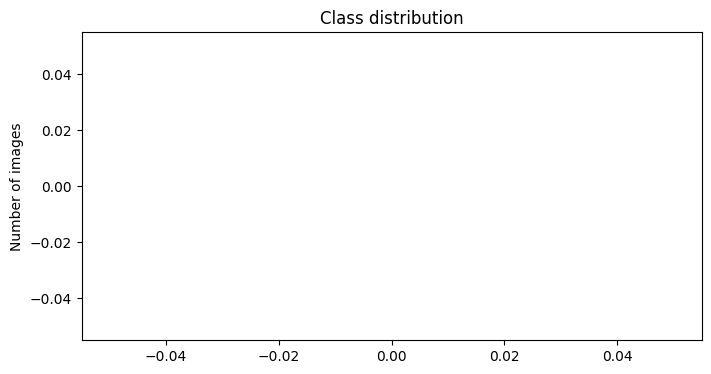

In [17]:
import matplotlib.pyplot as plt
classes = sorted([d.name for d in clean_dir.iterdir() if d.is_dir()])
counts = [len(list((clean_dir/c).glob('*'))) for c in classes]
plt.figure(figsize=(8,4))
plt.bar(classes, counts)
plt.title("Class distribution")
plt.ylabel("Number of images")
plt.show()
